# Week 1 — Data Cleaning and Exploratory Analysis (EDA)
## Final, Reproducible Notebook — bina.az Sale Listings (`house_sale.csv`)

This notebook consolidates all the work from Checkpoints 1–6 into a **single, clean, end-to-end pipeline**. Each section's reasoning is explained in detail in the separate checkpoint files — here I present the **final, runnable version** of those decisions, so the notebook runs error-free from top to bottom with "Run All."

**Structure:**
1. Data Loading & Preview
2. Null Value Handling (per-column strategy)
3. Outlier Detection & Processing
4. Feature Engineering
5. Visualization
6. Written Conclusion (5 key insights)


## 0. Importing libraries

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 70)
pd.set_option('display.width', 150)
sns.set_style("whitegrid")


## 1. Data Loading & Preview

Loading the dataset into Colab (reads directly if the file already exists locally, otherwise opens the upload widget), then examining its initial structure (shape, types, nulls, duplicates).

In [2]:
import os

FILE_NAME = "house_sale.csv"
if not os.path.exists(FILE_NAME):
    try:
        from google.colab import files
        uploaded = files.upload()
        FILE_NAME = list(uploaded.keys())[0]
    except ImportError:
        raise FileNotFoundError(f"{FILE_NAME} not found. Please upload the file.")

df = pd.read_csv(FILE_NAME)
print("Rows:", df.shape[0], "| Columns:", df.shape[1])
df.head(3)


Saving house_sale.csv to house_sale.csv
Rows: 100775 | Columns: 51


,id_x,rel_url,estate_rel_url_x,datetime_scrape_x,price,currency_x,location,attributes,city_when,city,day_x,hour_x,repair,vip,featured,products_label,bill_of_sale,mortgage,img_url,id_y,estate_id,estate_rel_url_y,datetime_scrape_y,description,unit_price,total_price,currency_y,owner_name,owner_title,shop_name,shop_title,address,lat,lng,updated,views,day_y,hour_y,estate_details_id_x,Binanın növü,Kateqoriya,Mərtəbə,Otaq sayı,Sahə,Torpaq sahəsi,Təmir,Çıxarış,İpoteka,estate_details_id_y,estate_rel_url,extra_info
0,5df36281-6dc6-4d5d-89a7-5fcfa86f7608,/alqi-satqi?page=174,/items/4521724,2024-10-05 22:07:37.60613+00,499999.0,AZN,Səbail r.,"4 otaqlı, 145 m², 7/9 mərtəbə","Bakı, dünən 23:52",bakı,05.10.2024,23:52,Təmirli,vipped,featured,NaN,Çıxarış var,NaN,https://bina.azstatic.com/uploads/f460x345/202...,92e82ea2-e1f3-4c2d-a284-151efd99281e,5df36281-6dc6-4d5d-89a7-5fcfa86f7608,/items/4521724,2024-10-05 22:14:10.089116+00,"Səbail Rayonu, İzzət Nəbiyev küçəsi, Fəxri Xiy...",3 450 AZN/m²,499999.0,AZN,Kamran,mülkiyyətçi,NaN,NaN,İzzət Nəbiyev küç.,40.358817,49.824092,yeniləndi: dünən 23:52,1155,05.10.2024,23:52,92e82ea2-e1f3-4c2d-a284-151efd99281e,NaN,Köhnə tikili,7 / 9,4.0,145 m²,NaN,var,var,NaN,92e82ea2-e1f3-4c2d-a284-151efd99281e,/items/4521724,Şəhidlər xiyabanı * Dağüstü parkı * Səbail r.
1,883e20f0-8872-49a5-8b4b-63b8301b5f8f,/alqi-satqi?page=250,/items/4669294,2024-10-05 22:07:37.60613+00,77000.0,AZN,Biləcəri q.,"4 otaqlı, 90 m²","Bakı, dünən 23:56",bakı,05.10.2024,23:56,Təmirli,NaN,NaN,NaN,NaN,NaN,https://bina.azstatic.com/uploads/f460x345/202...,505eaf81-6bc8-4094-9b00-aa82066548ee,883e20f0-8872-49a5-8b4b-63b8301b5f8f,/items/4669294,2024-10-05 22:14:10.089116+00,"Biləcəridə Abidəyə yaxin 91,92,202 saylı marşr...",NaN,77000.0,AZN,Dasinmaz Emlak,vasitəçi (agent),NaN,NaN,Biləcəri qəs.,40.420897,49.807035,yeniləndi: 04 oktyabr 2024,218,04.10.2024,NaN,505eaf81-6bc8-4094-9b00-aa82066548ee,NaN,Həyət evi/Bağ evi,NaN,4.0,90 m²,1.3 sot,var,yoxdur,NaN,505eaf81-6bc8-4094-9b00-aa82066548ee,/items/4669294,Binəqədi r.* Biləcəri q.
2,55c36fb1-a3af-476e-ba17-a81f6795be8d,/alqi-satqi?page=250,/items/4669293,2024-10-05 22:07:37.60613+00,92000.0,AZN,İnşaatçılar m.,"3 otaqlı, 60 m²","Bakı, dünən 23:55",bakı,05.10.2024,23:55,Təmirli,NaN,NaN,NaN,Çıxarış var,NaN,https://bina.azstatic.com/uploads/f460x345/202...,fa63b201-999d-43b5-a61a-778d9d79a6c6,55c36fb1-a3af-476e-ba17-a81f6795be8d,/items/4669293,2024-10-05 22:14:10.089116+00,Salam əleykum. \nİnşaatçılar metrosuna yaxın m...,NaN,92000.0,AZN,Məhəmməd,vasitəçi (agent),NaN,NaN,Mirzə Cabbar Məmmədzadə küç.,40.390293,49.802656,yeniləndi: 04 oktyabr 2024,190,04.10.2024,NaN,fa63b201-999d-43b5-a61a-778d9d79a6c6,NaN,Həyət evi/Bağ evi,NaN,3.0,60 m²,0.1 sot,var,var,NaN,fa63b201-999d-43b5-a61a-778d9d79a6c6,/items/4669293,İnşaatçılar m.* Yasamal r.


In [3]:
print("--- dtypes ---")
print(df.dtypes.value_counts())
print()
print("--- Full-row duplicates ---")
print(df.duplicated().sum())
print()
null_counts = df.isnull().sum()
null_percent = (null_counts / len(df) * 100).round(2)
null_summary = pd.DataFrame({"null_count": null_counts, "null_percent": null_percent}).sort_values("null_percent", ascending=False)
null_summary[null_summary["null_count"] > 0]


--- dtypes ---
object     45
float64     5
int64       1
Name: count, dtype: int64

--- Full-row duplicates ---
0



,null_count,null_percent
Binanın növü,100621,99.85
featured,97626,96.88
vip,92179,91.47
Torpaq sahəsi,85204,84.55
hour_y,85144,84.49
İpoteka,67836,67.31
mortgage,67836,67.31
shop_title,28757,28.54
shop_name,28757,28.54
products_label,28145,27.93


**Quick summary:** 100,775 rows × 51 columns, no full-row duplicates, 19 columns contain nulls (ranging from 0.26% to 99.85%).

## 2. Null Value Handling

For each column, I determined whether the missingness was **structural (MNAR)** or **random (MCAR)** by cross-checking against `Kateqoriya`. In short:
- Structural gaps (`Mərtəbə`, `Torpaq sahəsi`) — **left as-is** (not imputed).
- Single-value fields (`vip`, `featured`, `mortgage`, `bill_of_sale`) — **converted to boolean flags**.
- `unit_price` — **recalculated** from `price / Sahə` (instead of imputing).
- `Otaq sayı` — median-filled only within relevant categories.
- Mostly-empty/unusable columns (`Binanın növü`, `hour_y`, `repair`) — dropped.

In [4]:
df_clean = df.copy()
df_clean = df_clean.drop(columns=["Binanın növü", "hour_y"])

df_clean["featured_flag"] = df_clean["featured"].notnull()
df_clean["vip_flag"] = df_clean["vip"].notnull()
df_clean["mortgage_flag"] = df_clean["mortgage"].notnull()
df_clean["bill_of_sale_flag"] = df_clean["bill_of_sale"].notnull() | df_clean["Çıxarış"].notnull()
df_clean = df_clean.drop(columns=["featured", "vip", "mortgage", "İpoteka", "bill_of_sale", "Çıxarış", "repair"])
df_clean["Təmir"] = df_clean["Təmir"].fillna("Unknown")

def seller_type(row):
    if pd.notnull(row["shop_name"]):
        return "Agency"
    elif pd.notnull(row["owner_name"]):
        return "Individual"
    return "Unknown"

df_clean["seller_type"] = df_clean.apply(seller_type, axis=1)
for col in ["shop_name", "shop_title", "owner_name", "owner_title"]:
    df_clean[col] = df_clean[col].fillna("N/A")
df_clean["products_label"] = df_clean["products_label"].fillna("Regular listing")
df_clean["description"] = df_clean["description"].fillna("")

def parse_area(val):
    if pd.isnull(val):
        return np.nan
    val = val.strip()
    if "sot" in val:
        return float(val.replace("sot", "").strip().replace(",", ".")) * 100
    return float(val.replace("m²", "").strip().replace(" ", ""))

df_clean["Sahə_numeric"] = df_clean["Sahə"].apply(parse_area)
df_clean["unit_price_calculated"] = (df_clean["price"] / df_clean["Sahə_numeric"]).round(2)
df_clean = df_clean.drop(columns=["unit_price"])

applicable_categories = ["Köhnə tikili", "Yeni tikili", "Ofis", "Həyət evi/Bağ evi"]
mask = df_clean["Kateqoriya"].isin(applicable_categories)
medians = df_clean.loc[mask].groupby("Kateqoriya")["Otaq sayı"].median()
for cat, med in medians.items():
    idx = df_clean[(df_clean["Kateqoriya"] == cat) & (df_clean["Otaq sayı"].isnull())].index
    df_clean.loc[idx, "Otaq sayı"] = med

remaining_nulls = df_clean.isnull().sum()
print("Remaining nulls (only intentionally-kept structural columns):")
print(remaining_nulls[remaining_nulls > 0])


Remaining nulls (only intentionally-kept structural columns):
Mərtəbə          24779
Otaq sayı         9054
Torpaq sahəsi    85204
dtype: int64


## 3. Outlier Detection & Processing

Since key numeric columns had very high skewness (150–250 range), I used **IQR**, applied **grouped by `Kateqoriya`** (more accurate than global IQR). Obvious data-entry errors (e.g. 600M AZN) were removed separately with a sanity check first. Outliers were **capped** (winsorized) rather than deleted, to avoid losing potentially genuine luxury listings — an `is_outlier_*` flag is kept for each column.

In [5]:
before = len(df_clean)
df_clean = df_clean[df_clean["price"] >= 1000].copy()
print(f"Rows removed by sanity check: {before - len(df_clean)}")

def iqr_bounds(series, k=1.5):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

def cap_grouped(df, col, group_col="Kateqoriya", k=1.5):
    capped = df[col].copy()
    flag = pd.Series(False, index=df.index)
    for cat, group in df.groupby(group_col):
        low, high = iqr_bounds(group[col].dropna(), k)
        idx = group.index
        below = df.loc[idx, col] < low
        above = df.loc[idx, col] > high
        flag.loc[idx[below | above]] = True
        capped.loc[idx[below]] = low
        capped.loc[idx[above]] = high
    return capped, flag

df_clean["price_capped"], df_clean["is_outlier_price"] = cap_grouped(df_clean, "price")
df_clean["Sahə_numeric_capped"], df_clean["is_outlier_area"] = cap_grouped(df_clean, "Sahə_numeric")
df_clean["unit_price_capped"], df_clean["is_outlier_unit_price"] = cap_grouped(df_clean, "unit_price_calculated")

low_v, high_v = iqr_bounds(df_clean["views"])
df_clean["views_capped"] = df_clean["views"].clip(low_v, high_v)
df_clean["is_outlier_views"] = (df_clean["views"] < low_v) | (df_clean["views"] > high_v)

print("Outlier percentages:")
for c in ["is_outlier_price", "is_outlier_area", "is_outlier_unit_price", "is_outlier_views"]:
    print(f"  {c}: {df_clean[c].mean()*100:.2f}%")


Rows removed by sanity check: 10
Outlier percentages:
  is_outlier_price: 5.80%
  is_outlier_area: 4.05%
  is_outlier_unit_price: 3.33%
  is_outlier_views: 10.36%


## 4. Feature Engineering

Creating 4 new feature groups:
1. Floor-position indicators (`floor_ratio`, `is_top_floor`, `is_ground_floor`)
2. `location_type` — district center / micro-district / settlement
3. `price_per_room`
4. `price_index_vs_category` — price relative to category median

In [6]:
floor_split = df_clean["Mərtəbə"].str.split("/", expand=True)
df_clean["floor_current"] = pd.to_numeric(floor_split[0].str.strip(), errors="coerce")
df_clean["floor_total"] = pd.to_numeric(floor_split[1].str.strip(), errors="coerce")
df_clean["floor_ratio"] = (df_clean["floor_current"] / df_clean["floor_total"]).round(2)
df_clean["is_top_floor"] = df_clean["floor_current"] == df_clean["floor_total"]
df_clean["is_ground_floor"] = df_clean["floor_current"] == 1

def loc_type(loc):
    if pd.isnull(loc):
        return "Unknown"
    match = re.search(r"\s(r|m|q)\.$", loc.strip())
    mapping = {"r": "District center", "m": "Micro-district", "q": "Settlement"}
    return mapping.get(match.group(1), "Other") if match else "Other"

df_clean["location_type"] = df_clean["location"].apply(loc_type)

df_clean["price_per_room"] = np.where(
    df_clean["Otaq sayı"] > 0, (df_clean["price_capped"] / df_clean["Otaq sayı"]).round(0), np.nan
)
category_median = df_clean.groupby("Kateqoriya")["price_capped"].transform("median")
df_clean["price_index_vs_category"] = (df_clean["price_capped"] / category_median).round(2)

print("Final column count:", df_clean.shape[1])


Final column count: 64


## 5. Visualization

Three visualization types: distribution graphs, correlation heatmap, categorical breakdown.

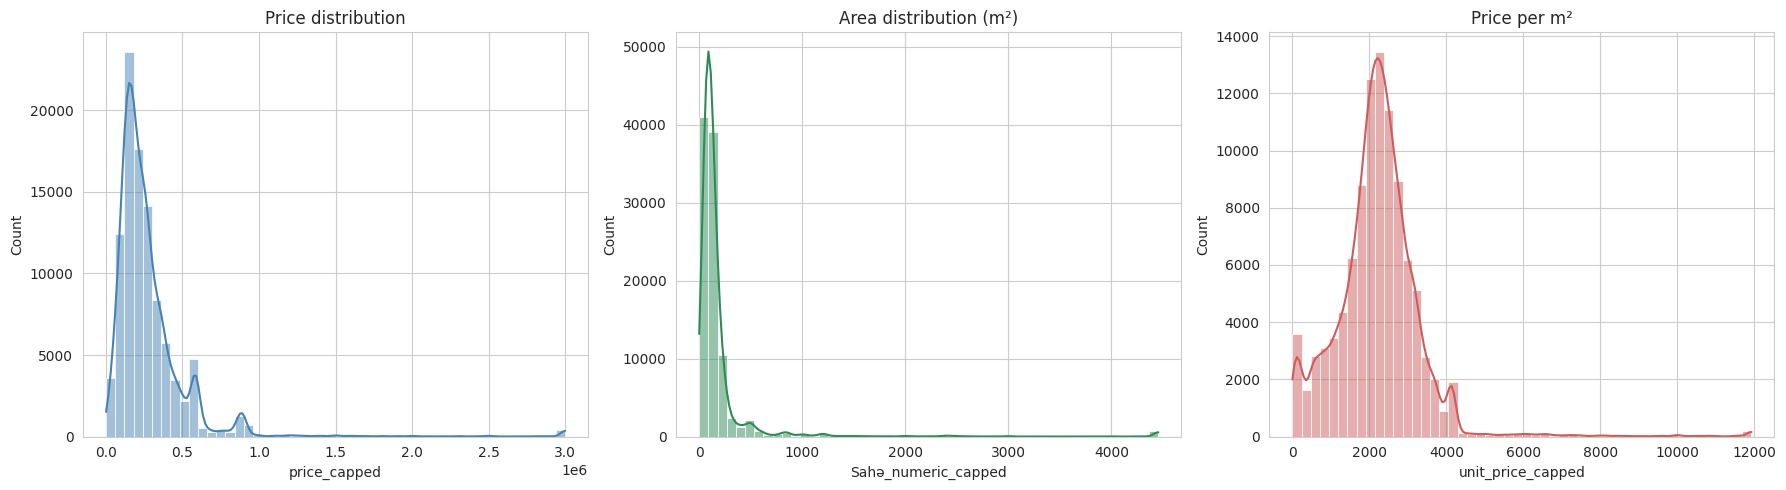

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(df_clean["price_capped"], bins=50, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Price distribution")
sns.histplot(df_clean["Sahə_numeric_capped"], bins=50, kde=True, ax=axes[1], color="seagreen")
axes[1].set_title("Area distribution (m²)")
sns.histplot(df_clean["unit_price_capped"], bins=50, kde=True, ax=axes[2], color="indianred")
axes[2].set_title("Price per m²")
plt.tight_layout()
plt.show()


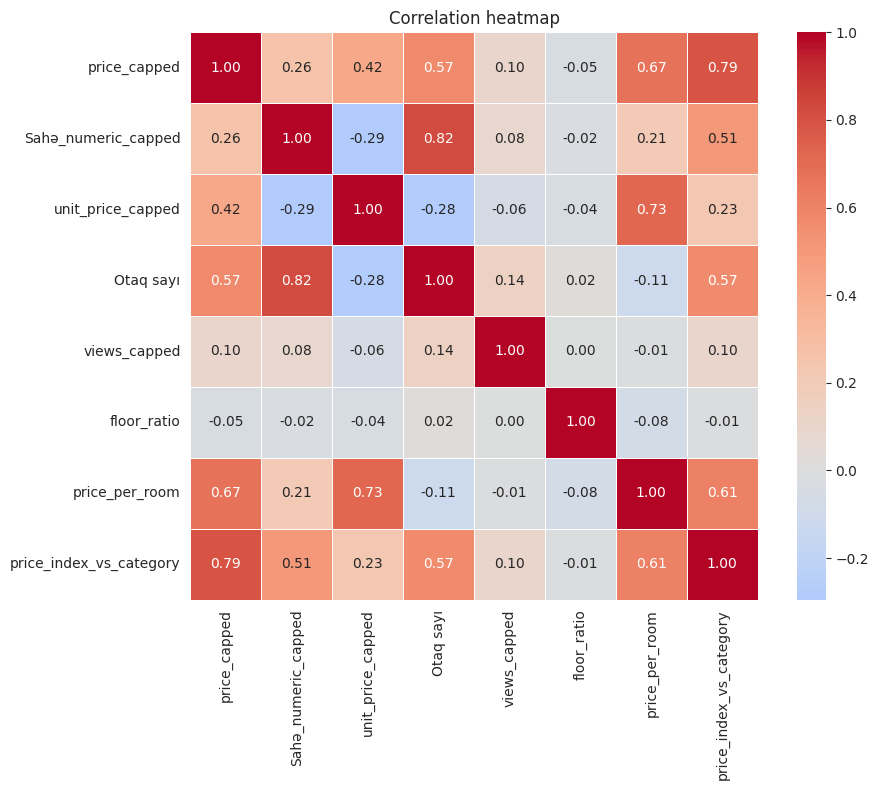

In [8]:
numeric_cols = ["price_capped", "Sahə_numeric_capped", "unit_price_capped", "Otaq sayı", "views_capped", "floor_ratio", "price_per_room", "price_index_vs_category"]
corr = df_clean[numeric_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, linewidths=0.5)
plt.title("Correlation heatmap")
plt.tight_layout()
plt.show()


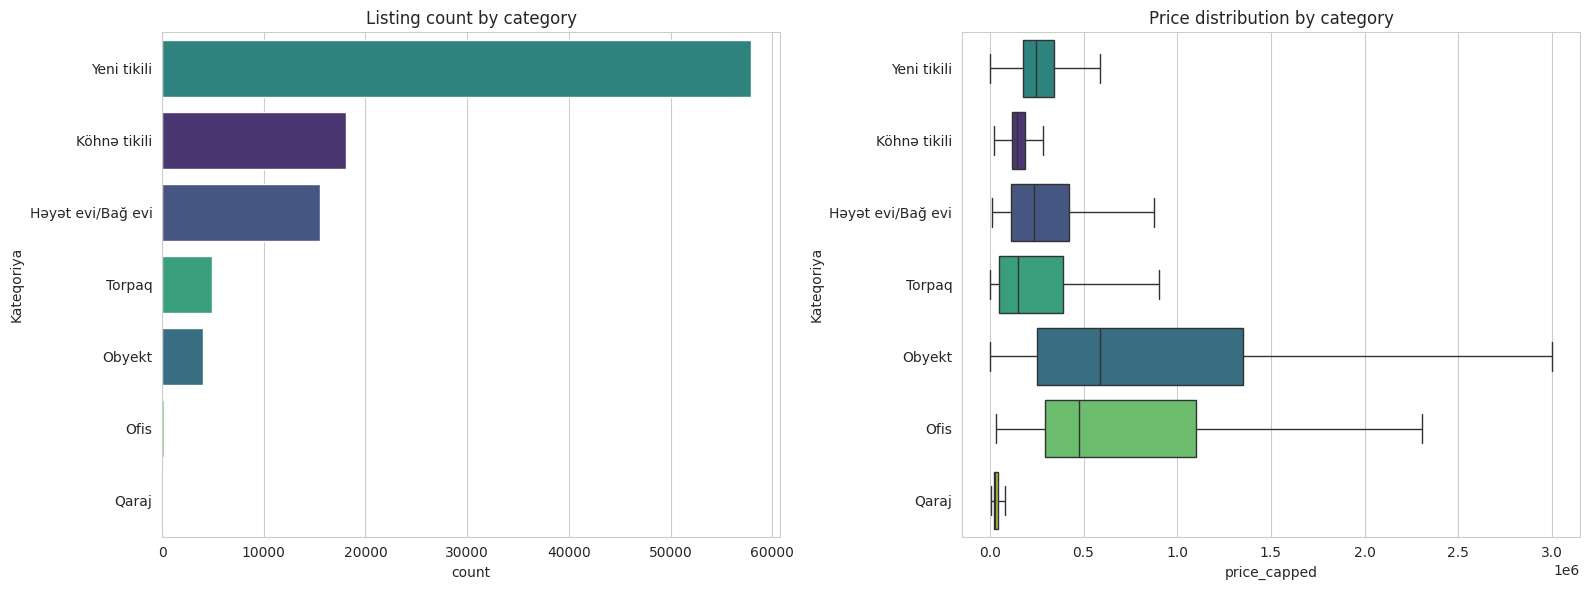

In [9]:
order = df_clean["Kateqoriya"].value_counts().index
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.countplot(data=df_clean, y="Kateqoriya", order=order, ax=axes[0], hue="Kateqoriya", legend=False, palette="viridis")
axes[0].set_title("Listing count by category")
sns.boxplot(data=df_clean, x="price_capped", y="Kateqoriya", order=order, ax=axes[1], hue="Kateqoriya", legend=False, palette="viridis")
axes[1].set_title("Price distribution by category")
plt.tight_layout()
plt.show()


## 6. Written Conclusion — Key Insights

Here I present the final 5 insights briefly.

In [10]:
category_share = (df_clean["Kateqoriya"].value_counts(normalize=True) * 100).round(1)
category_median_price = df_clean.groupby("Kateqoriya")["price_capped"].median().sort_values(ascending=False)
location_median_price = df_clean.groupby("location_type")["price_capped"].median().sort_values(ascending=False)
corr_room_price = df_clean[["Otaq sayı", "price_capped"]].corr().iloc[0, 1]
seller_median = df_clean.groupby("seller_type")["price_capped"].median()

print("1) New+Old construction share:", round(category_share[["Yeni tikili","Köhnə tikili"]].sum(),1), "%")
print("2) Most/least expensive category ratio:", round(category_median_price.max()/category_median_price.min(),1), "x")
print("3) District center vs Settlement gap:", round((location_median_price['District center']-location_median_price['Settlement'])/location_median_price['Settlement']*100), "%")
print("4) Room count vs price correlation:", round(corr_room_price,2))
print("5) Agency vs Individual price gap:", round((seller_median['Agency']-seller_median['Individual'])/seller_median['Individual']*100), "%")


1) New+Old construction share: 75.5 %
2) Most/least expensive category ratio: 19.7 x
3) District center vs Settlement gap: 45 %
4) Room count vs price correlation: 0.57
5) Agency vs Individual price gap: 41 %


**Final 5 insights:**

1. **Market structure:** ~75.5% of the Baku bina.az sale market is in the apartment segment (new/old construction).
2. **Category = price scale:** property category alone can shift price by up to ~19.7x (Object vs Garage).
3. **Location matters, even within Baku:** `location_type` creates up to ~45% of price variation.
4. **Room count is the strongest simple indicator:** `Otaq sayı` (0.57) outperforms `Sahə` (0.26).
5. **Seller type correlates with price, but causation should be interpreted carefully:** agency listings are ~41% pricier than individual ones.
